# RNA para Clasificación con Iris

Demo simple de red neuronal artificial en Keras para clasificar especies de flores.


## 1. Importar librerías


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, f1_score

from tensorflow import keras
from tensorflow.keras import layers


## 2. Cargar dataset
El dataset Iris tiene 3 clases: setosa, versicolor y virginica.


In [2]:
data = load_iris()
X = data.data
y = data.target

print("Forma de X:", X.shape)
print("Clases:", data.target_names)
print("Primeras 5 etiquetas:", y[:5])


Forma de X: (150, 4)
Clases: ['setosa' 'versicolor' 'virginica']
Primeras 5 etiquetas: [0 0 0 0 0]


## 3. Separar entrenamiento y validación
Usamos `stratify=y` para conservar la proporción de clases.


In [3]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Entrenamiento:", X_train.shape, y_train.shape)
print("Validación:", X_val.shape, y_val.shape)


Entrenamiento: (120, 4) (120,)
Validación: (30, 4) (30,)


## 4. Estandarizar variables


In [4]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)


## 5. Crear la red neuronal
Como es clasificación multiclase, la salida tiene 3 neuronas con `softmax`.


In [5]:
model = keras.Sequential([
    keras.Input(shape=(X_train.shape[1],)),
    layers.Dense(16, activation="relu"),
    layers.Dense(8, activation="relu"),
    layers.Dense(3, activation="softmax")
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243 (972.00 B)

 Trainable params: 243 (972.00 B)

 Non-trainable params: 0 (0.00 B)

## 6. Compilar modelo


In [6]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


## 7. Entrenar modelo


In [7]:
history = model.fit(
    X_train, y_train,
    epochs=40,
    batch_size=16,
    validation_data=(X_val, y_val),
    verbose=1
)


Epoch 1/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.3833 - loss: 1.1353 - val_accuracy: 0.3333 - val_loss: 1.1203
Epoch 2/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5083 - loss: 1.0620 - val_accuracy: 0.4333 - val_loss: 1.0536
Epoch 3/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6167 - loss: 0.9953 - val_accuracy: 0.5333 - val_loss: 0.9943
Epoch 4/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6667 - loss: 0.9352 - val_accuracy: 0.6333 - val_loss: 0.9403
Epoch 5/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7250 - loss: 0.8803 - val_accuracy: 0.6667 - val_loss: 0.8903
Epoch 6/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7667 - loss: 0.8335 - val_accuracy: 0.7000 - val_loss: 0.8447
Epoch 7/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7917 - loss: 0.7873 - val_accuracy: 0.7000 - val_loss: 0.8075
Epoch 8/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7750 - loss: 0.7508 - val_accuracy: 0.7000 - val_loss: 0.7737
Epoch 9

## 8. Evaluar modelo


In [8]:
loss, accuracy = model.evaluate(X_val, y_val, verbose=0)
print(f"Accuracy: {accuracy:.4f}")


Accuracy: 0.9000


## 9. Predicciones y métricas


In [9]:
y_pred_prob = model.predict(X_val)
y_pred = np.argmax(y_pred_prob, axis=1)

print("F1-score macro:", round(f1_score(y_val, y_pred, average="macro"), 4))
print("\nMatriz de confusión:")
print(confusion_matrix(y_val, y_pred))

print("\nReporte de clasificación:")
print(classification_report(y_val, y_pred, target_names=data.target_names))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
F1-score macro: 0.8977

Matriz de confusión:
[[10  0  0]
 [ 0  7  3]
 [ 0  0 10]]

Reporte de clasificación:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.70      0.82        10
   virginica       0.77      1.00      0.87        10

    accuracy                           0.90        30
   macro avg       0.92      0.90      0.90        30
weighted avg       0.92      0.90      0.90        30



## 10. Graficar entrenamiento


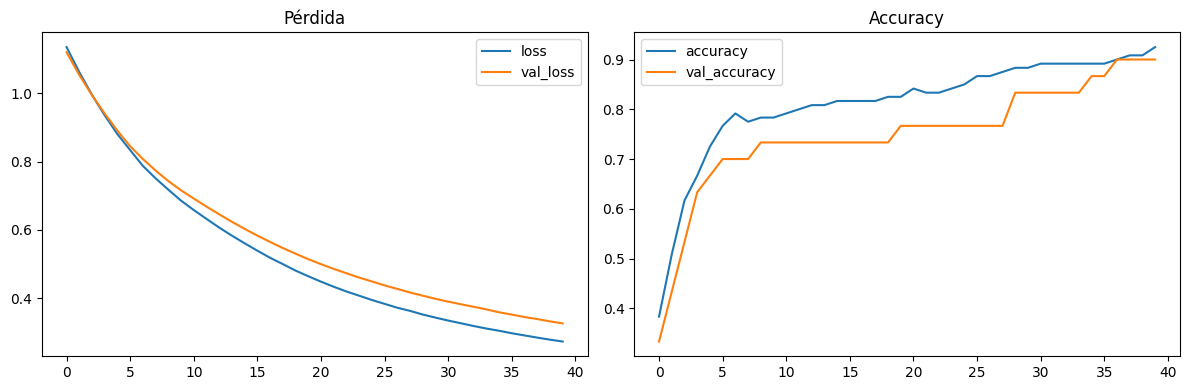

In [10]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title("Pérdida")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["accuracy"], label="accuracy")
plt.plot(history.history["val_accuracy"], label="val_accuracy")
plt.title("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


## 11. Probar una predicción individual


In [11]:
idx = 0
muestra = X_val[idx:idx+1]
pred = model.predict(muestra)
clase_pred = np.argmax(pred, axis=1)[0]
clase_real = y_val[idx]

print("Clase real:", data.target_names[clase_real])
print("Clase predicha:", data.target_names[clase_pred])
print("Probabilidades:", pred[0])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
Clase real: setosa
Clase predicha: setosa
Probabilidades: [0.97379184 0.02440521 0.00180295]
